# Estudo de caso: NEM, estrutura do Ensino Medio e desempenho no SAEB

Este notebook valida e compara os exports do MongoDB e Neo4j e responde, em nivel municipal, as perguntas sobre:

1. expansao do Ensino Medio integral e variacao do SAEB;
2. mudancas na estrutura das escolas regulares de EM;
3. coexistencia de EM e educacao tecnica na mesma escola;
4. relacao entre contexto socioeconomico e desempenho.

**Unidade analitica:** municipio. O SAEB nao esta no grao escola. As associacoes apresentadas nao identificam efeito causal do NEM.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
px.defaults.template = "plotly_white"

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
EXPORT_DIR = ROOT / "data" / "processed" / "no_sql_exports"
assert EXPORT_DIR.exists(), f"Diretorio nao encontrado: {EXPORT_DIR}"


In [2]:
FILES = {
    "m1": "mongodb_m1_painel_em_integral_saeb_2019_2023.csv",
    "m2": "mongodb_m2_estrutura_escolas_em_2019_2023.csv",
    "m3": "mongodb_m3_em_tecnico_mesma_escola_2023.csv",
    "m4": "mongodb_m4_contexto_socioeconomico_saeb_2023.csv",
    "n1": "neo4j_n1_painel_em_integral_saeb_2019_2023.csv",
    "n2": "neo4j_n2_estrutura_escolas_em_2019_2023.csv",
    "n3": "neo4j_n3_em_tecnico_mesma_escola_2023.csv",
    "n4": "neo4j_n4_contexto_socioeconomico_saeb_2023.csv",
}

data = {key: pd.read_csv(EXPORT_DIR / filename, dtype={"id_municipio": "string"}) for key, filename in FILES.items()}

inventory = pd.DataFrame([
    {
        "export": key,
        "arquivo": FILES[key],
        "linhas": len(df),
        "municipios_unicos": df["id_municipio"].nunique(),
        "duplicados": df["id_municipio"].duplicated().sum(),
        "nulos": int(df.isna().sum().sum()),
    }
    for key, df in data.items()
])
display(inventory)


,export,arquivo,linhas,municipios_unicos,duplicados,nulos
0,m1,mongodb_m1_painel_em_integral_saeb_2019_2023.csv,4453,4453,0,0
1,m2,mongodb_m2_estrutura_escolas_em_2019_2023.csv,4441,4441,0,0
2,m3,mongodb_m3_em_tecnico_mesma_escola_2023.csv,5026,5026,0,0
3,m4,mongodb_m4_contexto_socioeconomico_saeb_2023.csv,5033,5033,0,1780
4,n1,neo4j_n1_painel_em_integral_saeb_2019_2023.csv,4453,4453,0,0
5,n2,neo4j_n2_estrutura_escolas_em_2019_2023.csv,4441,4441,0,0
6,n3,neo4j_n3_em_tecnico_mesma_escola_2023.csv,5026,5026,0,0
7,n4,neo4j_n4_contexto_socioeconomico_saeb_2023.csv,5033,5033,0,1780


## 1. Paridade entre MongoDB e Neo4j

Os pares devem conter os mesmos municipios e os mesmos valores analiticos. Pequenas diferencas de ponto flutuante sao toleradas.


In [3]:
PAIR_COLUMNS = {
    "1": {
        "mongo": "m1", "neo": "n1",
        "rename_neo": {
            "saeb_2019": "media_saeb_2019", "saeb_2023": "media_saeb_2023",
            "integral_2019": "prop_mat_em_integral_2019",
            "integral_2023": "prop_mat_em_integral_2023",
        },
        "numeric": ["delta_saeb_2019_2023", "delta_prop_mat_em_integral_2019_2023"],
    },
    "2": {
        "mongo": "m2", "neo": "n2",
        "rename_neo": {
            "delta_prop_integral": "delta_prop_escolas_integral",
            "delta_prop_prof_tec": "delta_prop_escolas_prof_tec",
            "delta_prop_internet": "delta_prop_internet_aprendizagem",
        },
        "numeric": ["delta_saeb_2019_2023", "delta_prop_escolas_integral", "delta_prop_escolas_prof_tec",
                    "delta_prop_internet_aprendizagem", "delta_prop_biblioteca", "delta_prop_lab_ciencias"],
    },
    "3": {
        "mongo": "m3", "neo": "n3", "rename_neo": {},
        "numeric": ["escolas_em", "escolas_em_com_tecnico", "escolas_em_com_tecnico_nem",
                    "prop_escolas_em_com_tecnico", "prop_escolas_em_com_tecnico_nem", "media_saeb_2023"],
    },
    "4": {
        "mongo": "m4", "neo": "n4", "rename_neo": {},
        "numeric": ["qt_escolas_em", "qt_mat_med", "prop_mat_em_integral", "qt_mat_prof_tec",
                    "media_saeb_2023", "delta_saeb_2021_2023", "pib_per_capita", "taxa_alfabetizacao"],
    },
}

checks = []
for analysis, spec in PAIR_COLUMNS.items():
    mongo = data[spec["mongo"]].copy()
    neo = data[spec["neo"]].rename(columns=spec["rename_neo"]).copy()
    merged = mongo.merge(neo, on="id_municipio", how="outer", suffixes=("_mongo", "_neo"), indicator=True)
    max_diff = 0.0
    mismatches = 0
    for col in spec["numeric"]:
        left = pd.to_numeric(merged[f"{col}_mongo"], errors="coerce")
        right = pd.to_numeric(merged[f"{col}_neo"], errors="coerce")
        diff = (left - right).abs()
        max_diff = max(max_diff, float(diff.max(skipna=True) or 0))
        mismatches += int((diff.fillna(0) > 1e-9).sum())
    checks.append({
        "analise": analysis,
        "somente_mongo": int((merged["_merge"] == "left_only").sum()),
        "somente_neo4j": int((merged["_merge"] == "right_only").sum()),
        "divergencias_numericas": mismatches,
        "maior_diferenca": max_diff,
    })

parity = pd.DataFrame(checks)
display(parity)
assert not parity[["somente_mongo", "somente_neo4j", "divergencias_numericas"]].to_numpy().any(), "Exports divergentes"


,analise,somente_mongo,somente_neo4j,divergencias_numericas,maior_diferenca
0,1,0,0,0,9.937391e-17
1,2,0,0,0,1.399922e-15
2,3,0,0,0,0.000000e+00
3,4,0,0,0,9.790346e-17


In [4]:
fig = px.bar(
    inventory, x="export", y="linhas", color=inventory["export"].str[0].map({"m": "MongoDB", "n": "Neo4j"}),
    barmode="group", labels={"color": "Banco", "linhas": "Municipios", "export": "Export"},
    title="Cobertura dos exports por banco",
)
fig.show()


## 2. Pergunta principal: expansao do EM integral e variacao do SAEB

A analise de mudancas 2019-2023 e preferivel a uma comparacao apenas transversal. Ela relaciona a mudanca na proporcao de matriculas integrais a mudanca na media municipal do SAEB.


In [5]:
def correlation_table(df, outcome, predictors):
    rows = []
    for predictor in predictors:
        pair = df[[predictor, outcome]].dropna()
        rows.append({
            "indicador": predictor,
            "n": len(pair),
            "pearson": pair[predictor].corr(pair[outcome], method="pearson"),
            "spearman": pair[predictor].corr(pair[outcome], method="spearman"),
        })
    return pd.DataFrame(rows)

m1 = data["m1"].copy()
corr_m1 = correlation_table(
    m1, "delta_saeb_2019_2023", ["delta_prop_mat_em_integral_2019_2023"]
)
display(corr_m1)

fig = px.scatter(
    m1, render_mode="svg", x="delta_prop_mat_em_integral_2019_2023", y="delta_saeb_2019_2023",
    color="nome_regiao", opacity=0.45, hover_name="nome_municipio",
    labels={
        "delta_prop_mat_em_integral_2019_2023": "Mudanca na proporcao de matriculas integrais",
        "delta_saeb_2019_2023": "Mudanca SAEB LP/MT",
        "nome_regiao": "Regiao",
    },
    title="Expansao do EM integral versus variacao do SAEB (2019-2023)",
)
fig.add_hline(y=0, line_dash="dot", line_color="#555")
fig.add_vline(x=0, line_dash="dot", line_color="#555")
fig.show()


,indicador,n,pearson,spearman
0,delta_prop_mat_em_integral_2019_2023,4453,0.033502,-0.001401


## 3. Estrutura das escolas regulares de EM

Cada indicador representa a mudanca na proporcao de escolas de EM do municipio que possui a caracteristica entre 2019 e 2023.


In [6]:
m2 = data["m2"].copy()
structural = [
    "delta_prop_escolas_integral", "delta_prop_escolas_prof_tec",
    "delta_prop_internet_aprendizagem", "delta_prop_biblioteca", "delta_prop_lab_ciencias",
]
corr_m2 = correlation_table(m2, "delta_saeb_2019_2023", structural)
display(corr_m2.sort_values("spearman", key=abs, ascending=False))

heat = corr_m2.set_index("indicador")[["pearson", "spearman"]]
fig = px.imshow(
    heat, text_auto=".3f", aspect="auto", color_continuous_scale="RdBu", zmin=-1, zmax=1,
    title="Correlacoes entre mudancas estruturais e variacao do SAEB",
)
fig.show()


,indicador,n,pearson,spearman
2,delta_prop_internet_aprendizagem,4441,-0.003100,-0.049964
4,delta_prop_lab_ciencias,4441,0.007346,0.022132
0,delta_prop_escolas_integral,4441,-0.005578,-0.019301
1,delta_prop_escolas_prof_tec,4441,0.048093,0.018461
3,delta_prop_biblioteca,4441,-0.011902,0.011815


## 4. Coexistencia de EM e tecnico na mesma escola

Esta analise e transversal em 2023. Ela compara municipios sem e com escolas que ofertam simultaneamente EM e educacao tecnica. Diferencas nao devem ser interpretadas como efeito da oferta tecnica.


In [7]:
m3 = data["m3"].copy()
m3["grupo_tecnico"] = np.where(m3["escolas_em_com_tecnico"] > 0, "Com EM + tecnico", "Sem EM + tecnico")
m3["grupo_tecnico_nem"] = np.where(m3["escolas_em_com_tecnico_nem"] > 0, "Com oferta tecnica NEM", "Sem oferta tecnica NEM")

summary_m3 = m3.groupby("grupo_tecnico", observed=True).agg(
    municipios=("id_municipio", "nunique"),
    media_saeb_2023=("media_saeb_2023", "mean"),
    mediana_saeb_2023=("media_saeb_2023", "median"),
    media_prop_escolas=("prop_escolas_em_com_tecnico", "mean"),
).reset_index()
display(summary_m3)

fig = px.box(
    m3, x="grupo_tecnico", y="media_saeb_2023", color="grupo_tecnico",
    points=False, labels={"grupo_tecnico": "Oferta no municipio", "media_saeb_2023": "SAEB LP/MT 2023"},
    title="Distribuicao do SAEB em municipios com e sem EM + tecnico na mesma escola",
)
fig.update_layout(showlegend=False)
fig.show()


,grupo_tecnico,municipios,media_saeb_2023,mediana_saeb_2023,media_prop_escolas
0,Com EM + tecnico,696,266.263369,267.3175,0.478054
1,Sem EM + tecnico,4330,267.866803,267.6875,0.000000


## 5. Contexto socioeconomico

O arquivo M4 cobre o nivel do SAEB 2023 em todos os municipios elegiveis. Para analisar a variacao 2021-2023, as linhas sem delta sao removidas apenas naquele calculo.


**Correlacoes com o nivel SAEB 2023**

,indicador,n,pearson,spearman
0,pib_per_capita,5033,0.162763,0.355778
1,taxa_alfabetizacao,5033,0.405039,0.441970
2,prop_mat_em_integral,5033,0.060308,0.003642
3,qt_mat_prof_tec,5033,0.005728,0.000492


**Correlacoes com a variacao SAEB 2021-2023**

,indicador,n,pearson,spearman
0,pib_per_capita,3253,-0.097468,-0.154149
1,taxa_alfabetizacao,3253,-0.157011,-0.209467
2,prop_mat_em_integral,3253,0.025605,0.005035
3,qt_mat_prof_tec,3253,-0.040304,-0.059103


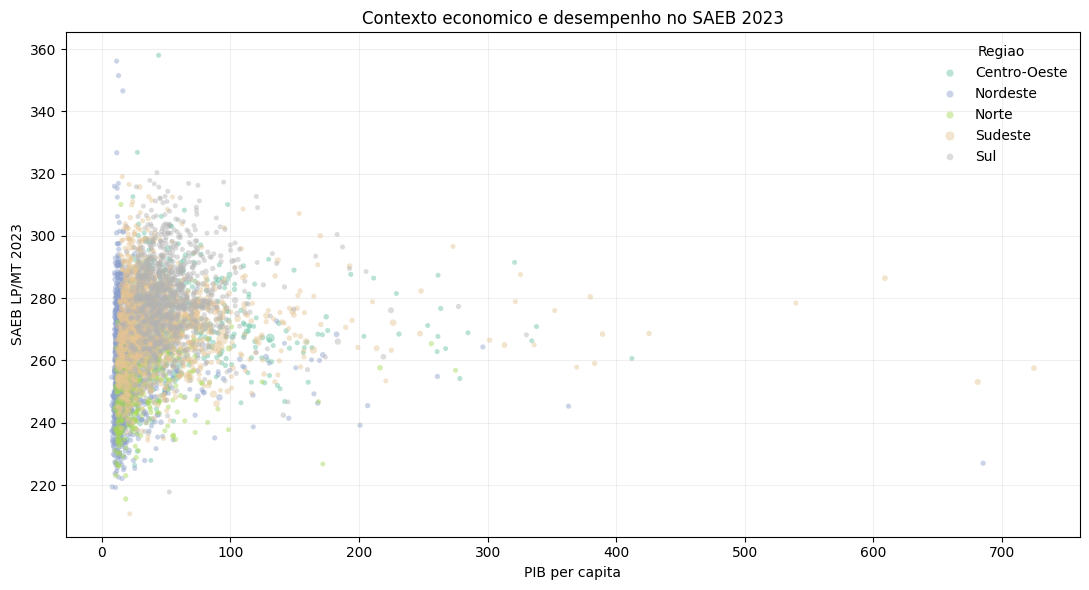

In [8]:
m4 = data["m4"].copy()
context_level = correlation_table(
    m4, "media_saeb_2023", ["pib_per_capita", "taxa_alfabetizacao", "prop_mat_em_integral", "qt_mat_prof_tec"]
)
context_delta = correlation_table(
    m4.dropna(subset=["delta_saeb_2021_2023"]), "delta_saeb_2021_2023",
    ["pib_per_capita", "taxa_alfabetizacao", "prop_mat_em_integral", "qt_mat_prof_tec"],
)
display(Markdown("**Correlacoes com o nivel SAEB 2023**"), context_level)
display(Markdown("**Correlacoes com a variacao SAEB 2021-2023**"), context_delta)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))
regions = sorted(m4["nome_regiao"].dropna().unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(regions)))

for region, color in zip(regions, colors):
    subset = m4[m4["nome_regiao"] == region]
    sizes = 12 + 60 * np.sqrt(subset["qt_mat_med"] / m4["qt_mat_med"].max())
    ax.scatter(
        subset["pib_per_capita"],
        subset["media_saeb_2023"],
        s=sizes,
        alpha=0.45,
        color=color,
        label=region,
        edgecolors="none",
    )

ax.set_title("Contexto economico e desempenho no SAEB 2023")
ax.set_xlabel("PIB per capita")
ax.set_ylabel("SAEB LP/MT 2023")
ax.grid(alpha=0.2)
ax.legend(title="Regiao", frameon=False)
plt.tight_layout()
plt.show()


## 6. Sintese automatica do estudo de caso

A celula abaixo resume direcao e magnitude das associacoes. A interpretacao final deve considerar cobertura, confundimento e a natureza observacional dos dados.


In [9]:
def describe_strength(value):
    magnitude = abs(value)
    if magnitude < 0.10:
        return "muito fraca"
    if magnitude < 0.30:
        return "fraca"
    if magnitude < 0.50:
        return "moderada"
    return "forte"

r_integral = corr_m1.loc[0, "spearman"]
best_structure = corr_m2.iloc[corr_m2["spearman"].abs().argmax()]
saeb_groups = summary_m3.set_index("grupo_tecnico")["media_saeb_2023"]
diff_technical = saeb_groups.get("Com EM + tecnico", np.nan) - saeb_groups.get("Sem EM + tecnico", np.nan)
r_pib = context_level.set_index("indicador").loc["pib_per_capita", "spearman"]
r_alpha = context_level.set_index("indicador").loc["taxa_alfabetizacao", "spearman"]
mean_integral_2019 = m1["prop_mat_em_integral_2019"].mean()
mean_integral_2023 = m1["prop_mat_em_integral_2023"].mean()
mean_saeb_2019 = m1["media_saeb_2019"].mean()
mean_saeb_2023 = m1["media_saeb_2023"].mean()

summary = f"""
### Evidencias encontradas

- A associacao monotonica entre expansao das matriculas de EM integral e variacao do SAEB foi **{describe_strength(r_integral)}** (Spearman = {r_integral:.3f}).
- Entre os indicadores estruturais, `{best_structure['indicador']}` apresentou a maior correlacao absoluta com a variacao do SAEB (Spearman = {best_structure['spearman']:.3f}), ainda sujeita a confundimento.
- A diferenca bruta da media SAEB entre municipios com e sem EM + tecnico na mesma escola foi {diff_technical:.2f} pontos.
- PIB per capita e alfabetizacao apresentaram correlacoes de Spearman de {r_pib:.3f} e {r_alpha:.3f}, respectivamente, com o nivel SAEB 2023.

### Resposta à pergunta principal

A proporção média de matrículas de EM integral passou de {mean_integral_2019:.1%} para {mean_integral_2023:.1%}, enquanto a média municipal do SAEB passou de {mean_saeb_2019:.2f} para {mean_saeb_2023:.2f}. Apesar dessas evoluções simultâneas, a associação entre as mudanças foi {describe_strength(r_integral)}.

Com os dados e proxies disponíveis, **não foi identificada associação municipal relevante entre a expansão do EM integral, as mudanças estruturais ligadas ao NEM e a variação do SAEB**. Isso não prova ausência de impacto do NEM; significa que este desenho observacional não encontrou evidência de um impacto associado mensurável no SAEB.

Tempo integral, oferta profissional, infraestrutura e contexto socioeconômico representam dimensões distintas e não devem ser combinados em um único indicador sem justificativa metodológica.

### Limitacoes

- SAEB agregado por municipio, sem resultado individual por escola.
- Implementacao do NEM representada por proxies, nao por uma medida normativa completa.
- Pandemia e politicas estaduais coincidem com o periodo analisado.
- A comparacao EM + tecnico em 2023 e transversal e sujeita a selecao da oferta.
- Ausencia de indicadores de abandono e reprovacao na serving atual.
"""
display(Markdown(summary))



### Evidencias encontradas

- A associacao monotonica entre expansao das matriculas de EM integral e variacao do SAEB foi **muito fraca** (Spearman = -0.001).
- Entre os indicadores estruturais, `delta_prop_internet_aprendizagem` apresentou a maior correlacao absoluta com a variacao do SAEB (Spearman = -0.050), ainda sujeita a confundimento.
- A diferenca bruta da media SAEB entre municipios com e sem EM + tecnico na mesma escola foi -1.60 pontos.
- PIB per capita e alfabetizacao apresentaram correlacoes de Spearman de 0.356 e 0.442, respectivamente, com o nivel SAEB 2023.

### Resposta à pergunta principal

A proporção média de matrículas de EM integral passou de 10.4% para 24.7%, enquanto a média municipal do SAEB passou de 272.18 para 267.93. Apesar dessas evoluções simultâneas, a associação entre as mudanças foi muito fraca.

Com os dados e proxies disponíveis, **não foi identificada associação municipal relevante entre a expansão do EM integral, as mudanças estruturais ligadas ao NEM e a variação do SAEB**. Isso não prova ausência de impacto do NEM; significa que este desenho observacional não encontrou evidência de um impacto associado mensurável no SAEB.

Tempo integral, oferta profissional, infraestrutura e contexto socioeconômico representam dimensões distintas e não devem ser combinados em um único indicador sem justificativa metodológica.

### Limitacoes

- SAEB agregado por municipio, sem resultado individual por escola.
- Implementacao do NEM representada por proxies, nao por uma medida normativa completa.
- Pandemia e politicas estaduais coincidem com o periodo analisado.
- A comparacao EM + tecnico em 2023 e transversal e sujeita a selecao da oferta.
- Ausencia de indicadores de abandono e reprovacao na serving atual.


## Proximos passos metodologicos

Para uma analise inferencial mais robusta, ajustar modelos municipais com SAEB inicial, PIB per capita, alfabetizacao, regiao/UF e tamanho da rede. Reportar coeficientes, intervalos de confianca, diagnosticos de residuos e analises de sensibilidade, mantendo a conclusao no campo associativo.


## Síntese das mudanças, contexto e conclusão

### Mudanças observadas entre 2019 e 2023

| Indicador — média municipal | Mudança observada |
|---|---:|
| Matrículas no EM integral | 10,4% → 24,7% |
| Expansão das matrículas no EM integral | +14,3 pontos percentuais |
| Média municipal do SAEB | 272,18 → 267,93 |
| Variação média do SAEB | −4,25 pontos |
| Proporção de escolas de EM integral | +35,0 pontos percentuais |
| Proporção de escolas com educação profissional/técnica | +11,0 pontos percentuais |
| Proporção de escolas com internet para aprendizagem | +13,9 pontos percentuais |
| Proporção de escolas com biblioteca | +1,1 ponto percentual |
| Proporção de escolas com laboratório de ciências | +2,5 pontos percentuais |

> Os valores representam médias entre municípios e não taxas nacionais ponderadas pelo número de matrículas.

### Pontos principais de contexto

- A expansão das matrículas integrais praticamente não apresentou relação com a variação municipal do SAEB (Pearson = 0,034; Spearman = −0,001).
- As mudanças de infraestrutura e oferta educacional também tiveram correlações muito fracas com a variação do SAEB. A maior correlação absoluta foi a de internet para aprendizagem (Spearman = −0,050), ainda sem relevância substantiva.
- Em 2023, municípios com escolas que ofereciam simultaneamente EM e educação técnica tiveram SAEB médio de 266,26, contra 267,87 nos demais: diferença bruta de aproximadamente −1,60 ponto. Por ser uma comparação transversal, isso não representa efeito da oferta técnica.
- O nível do SAEB em 2023 esteve mais associado à taxa de alfabetização (Spearman = 0,442) e ao PIB per capita (Spearman = 0,356) do que à proporção de matrículas integrais (0,004) ou à quantidade de matrículas técnicas (0,0005).
- O SAEB está agregado no nível municipal. A pandemia, políticas estaduais, diferenças regionais e o uso de proxies para a implementação do NEM limitam a interpretação dos resultados.

### Conclusão

Entre 2019 e 2023, houve expansão do Ensino Médio integral, da educação profissional e de alguns recursos escolares. Entretanto, essas mudanças ocorreram simultaneamente a uma redução média de aproximadamente 4,25 pontos no SAEB e não apresentaram associação municipal relevante com a variação do desempenho.

Assim, o estudo **não encontrou evidências de uma mudança mensurável no SAEB associada à expansão do EM integral ou às mudanças estruturais relacionadas ao NEM**. Isso não prova ausência de impacto do NEM; indica que, com dados agregados por município e um desenho observacional, não foi possível identificar esse impacto. Os resultados sugerem que o contexto socioeconômico, especialmente a alfabetização e o PIB per capita, está mais relacionado ao nível de desempenho observado em 2023.
